In [1]:
# ===============================
# Step 2: Basic Data Exploration
# ===============================

import pandas as pd

# Load dataset
df = pd.read_csv("../data/IPL.csv", low_memory=False)

# 1. Dataset shape
print("Dataset Shape:")
print(df.shape)

print("\n---------------------------------\n")

# 2. Column names
print("Column Names:")
print(df.columns)

print("\n---------------------------------\n")

# 3. Dataset information
print("Dataset Info:")
print(df.info())

print("\n---------------------------------\n")

# 4. Missing values
print("Missing Values:")
print(df.isnull().sum().sort_values(ascending=False))

Dataset Shape:
(278205, 64)

---------------------------------

Column Names:
Index(['Unnamed: 0', 'match_id', 'date', 'Unnamed: 3', 'Unnamed: 4', 'innings',
       'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter',
       'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball',
       'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary',
       'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind',
       'player_out', 'fielders', 'runs_target', 'review_batter',
       'team_reviewed', 'review_decision', 'umpire', 'umpires_call',
       'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner',
       'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season',
       'gender', 'team_type', 'superover_winner', 'result_type', 'method',
       'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number',
       'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'batter_runs',
       'batter_balls', 'bowler_wicket', '

In [2]:
# ===============================
# Step 3: Check for Null Values
# ===============================

# Check number of missing values in each column
null_values = df.isnull().sum()

# Show only columns that have missing values
null_values = null_values[null_values > 0].sort_values(ascending=False)

print("Columns with Missing Values:")
print(null_values)

print("\nTotal Missing Values in Dataset:", df.isnull().sum().sum())

# Percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

print("\nPercentage of Missing Values:")
print(missing_percentage)

Columns with Missing Values:
Unnamed: 3          278205
Unnamed: 4          278205
team_reviewed       277333
review_batter       277333
review_decision     277333
umpire              277333
method              274315
superover_winner    274309
result_type         273503
fielders            268192
new_batter          264884
next_batter         264884
wicket_kind         264382
player_out          264382
extra_type          263072
runs_target         144302
win_outcome           4702
dtype: int64

Total Missing Values in Dataset: 4226669

Percentage of Missing Values:
Unnamed: 3          100.000000
Unnamed: 4          100.000000
team_reviewed        99.686562
review_batter        99.686562
review_decision      99.686562
umpire               99.686562
method               98.601751
superover_winner     98.599594
result_type          98.309879
fielders             96.400855
new_batter           95.211804
next_batter          95.211804
wicket_kind          95.031362
player_out           95

In [3]:
# ===============================
# Step 4: Remove Useless Columns
# ===============================

# Drop columns with more than 80% missing values
threshold = 0.8
missing_ratio = df.isnull().mean()

cols_to_drop = missing_ratio[missing_ratio > threshold].index

df_cleaned = df.drop(columns=cols_to_drop)

print("Columns removed:", list(cols_to_drop))
print("\nNew dataset shape:", df_cleaned.shape)
print("\nRemaining columns:")
print(df_cleaned.columns)

Columns removed: ['Unnamed: 3', 'Unnamed: 4', 'extra_type', 'wicket_kind', 'player_out', 'fielders', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'superover_winner', 'result_type', 'method', 'new_batter', 'next_batter']

New dataset shape: (278205, 49)

Remaining columns:
Index(['Unnamed: 0', 'match_id', 'date', 'innings', 'batting_team',
       'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos',
       'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras',
       'runs_total', 'runs_bowler', 'runs_not_boundary', 'non_striker',
       'non_striker_pos', 'runs_target', 'umpires_call', 'player_of_match',
       'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue',
       'city', 'day', 'month', 'year', 'season', 'gender', 'team_type',
       'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number',
       'team_runs', 'team_balls', 'team_wicket', 'batter_runs', 'batter_balls',
       'bowler_wicket', 'batting_partn

In [4]:
# ===============================
# Convert Ball-by-Ball → Match-Level Data
# ===============================

# Columns we need for match prediction
match_columns = [
    "match_id",
    "batting_team",
    "bowling_team",
    "toss_winner",
    "toss_decision",
    "venue",
    "city",
    "match_won_by"
]

# Keep only columns that exist in the dataset
match_columns = [col for col in match_columns if col in df_cleaned.columns]

match_df = df_cleaned[match_columns]

# Convert ball-by-ball rows into match-level rows
match_df = match_df.groupby("match_id").first().reset_index()

# Rename target column
if "match_won_by" in match_df.columns:
    match_df = match_df.rename(columns={"match_won_by": "winner"})

# Remove matches without result
match_df = match_df.dropna(subset=["winner"])

# Display results
print("Match-level dataset shape:", match_df.shape)

print("\nColumns in dataset:")
print(match_df.columns)

print("\nFirst 5 rows:")
print(match_df.head())

Match-level dataset shape: (1169, 8)

Columns in dataset:
Index(['match_id', 'batting_team', 'bowling_team', 'toss_winner',
       'toss_decision', 'venue', 'city', 'winner'],
      dtype='object')

First 5 rows:
   match_id           batting_team                 bowling_team  \
0    335982  Kolkata Knight Riders  Royal Challengers Bangalore   
1    335983    Chennai Super Kings              Kings XI Punjab   
2    335984       Rajasthan Royals             Delhi Daredevils   
3    335985         Mumbai Indians  Royal Challengers Bangalore   
4    335986        Deccan Chargers        Kolkata Knight Riders   

                   toss_winner toss_decision  \
0  Royal Challengers Bangalore         field   
1          Chennai Super Kings           bat   
2             Rajasthan Royals           bat   
3               Mumbai Indians           bat   
4              Deccan Chargers           bat   

                                        venue        city  \
0                       M Chinnasw

In [5]:
# ===============================
# Check target variable distribution
# ===============================

print("Unique teams in winner column:\n")
print(match_df["winner"].unique())

print("\nNumber of matches won by each team:\n")
print(match_df["winner"].value_counts())

Unique teams in winner column:

['Kolkata Knight Riders' 'Chennai Super Kings' 'Delhi Daredevils'
 'Royal Challengers Bangalore' 'Rajasthan Royals' 'Kings XI Punjab'
 'Deccan Chargers' 'Mumbai Indians' 'Unknown' 'Pune Warriors'
 'Kochi Tuskers Kerala' 'Sunrisers Hyderabad' 'Rising Pune Supergiants'
 'Gujarat Lions' 'Rising Pune Supergiant' 'Delhi Capitals' 'Punjab Kings'
 'Gujarat Titans' 'Lucknow Super Giants' 'Royal Challengers Bengaluru']

Number of matches won by each team:

winner
Mumbai Indians                 151
Chennai Super Kings            142
Kolkata Knight Riders          135
Royal Challengers Bangalore    114
Rajasthan Royals               114
Sunrisers Hyderabad             93
Kings XI Punjab                 85
Delhi Daredevils                67
Delhi Capitals                  51
Gujarat Titans                  37
Punjab Kings                    34
Lucknow Super Giants            30
Deccan Chargers                 29
Unknown                         23
Royal Challengers B

In [6]:
# ===============================
# Clean team name inconsistencies (including RCB)
# ===============================

team_name_replacements = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    "Royal Challengers Bengaluru": "Royal Challengers Bangalore"
}

# Apply replacements to all team-related columns
match_df["winner"] = match_df["winner"].replace(team_name_replacements)
match_df["batting_team"] = match_df["batting_team"].replace(team_name_replacements)
match_df["bowling_team"] = match_df["bowling_team"].replace(team_name_replacements)
match_df["toss_winner"] = match_df["toss_winner"].replace(team_name_replacements)

# Remove rows with unknown winners
match_df = match_df[match_df["winner"] != "Unknown"]

# Verify cleaned teams
print("Unique teams after cleaning:\n")
print(sorted(match_df["winner"].unique()))

print("\nWinner distribution:\n")
print(match_df["winner"].value_counts())

print("\nDataset shape after cleaning:", match_df.shape)

Unique teams after cleaning:

['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Sunrisers Hyderabad']

Winner distribution:

winner
Mumbai Indians                 151
Chennai Super Kings            142
Kolkata Knight Riders          135
Royal Challengers Bangalore    132
Punjab Kings                   119
Delhi Capitals                 118
Rajasthan Royals               114
Sunrisers Hyderabad             93
Gujarat Titans                  37
Lucknow Super Giants            30
Deccan Chargers                 29
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64

Dataset shape after cleaning: (1146, 8)


In [7]:
# ===============================
# Step: Get all unique venue names
# ===============================

venues = sorted(match_df["venue"].dropna().unique())

print("Total unique venues:", len(venues))
print("\nList of all venues:\n")

for v in venues:
    print(v)

Total unique venues: 59

List of all venues:

Arun Jaitley Stadium
Arun Jaitley Stadium, Delhi
Barabati Stadium
Barsapara Cricket Stadium, Guwahati
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow
Brabourne Stadium
Brabourne Stadium, Mumbai
Buffalo Park
De Beers Diamond Oval
Dr DY Patil Sports Academy
Dr DY Patil Sports Academy, Mumbai
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam
Dubai International Cricket Stadium
Eden Gardens
Eden Gardens, Kolkata
Feroz Shah Kotla
Green Park
Himachal Pradesh Cricket Association Stadium
Himachal Pradesh Cricket Association Stadium, Dharamsala
Holkar Cricket Stadium
JSCA International Stadium Complex
Kingsmead
M Chinnaswamy Stadium
M Chinnaswamy Stadium, Bengaluru
M.Chinnaswamy Stadium
MA Chidambaram Stadium
MA Chidambaram Stadium, Chepauk
MA Chidambaram Stadium, Chepauk, Chennai
Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur
Maharaja Yada

In [8]:
# ===============================
# Standardize Venue Names
# ===============================

venue_replacements = {
    "Arun Jaitley Stadium, Delhi": "Arun Jaitley Stadium",
    "Brabourne Stadium, Mumbai": "Brabourne Stadium",
    "M Chinnaswamy Stadium, Bengaluru": "M Chinnaswamy Stadium",
    "M.Chinnaswamy Stadium": "M Chinnaswamy Stadium",
    "MA Chidambaram Stadium, Chepauk": "MA Chidambaram Stadium",
    "MA Chidambaram Stadium, Chepauk, Chennai": "MA Chidambaram Stadium",
    "Punjab Cricket Association IS Bindra Stadium, Mohali": "PCA IS Bindra Stadium",
    "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh": "PCA IS Bindra Stadium",
    "Punjab Cricket Association Stadium, Mohali": "PCA IS Bindra Stadium",
    "Rajiv Gandhi International Stadium, Uppal": "Rajiv Gandhi International Stadium",
    "Rajiv Gandhi International Stadium, Uppal, Hyderabad": "Rajiv Gandhi International Stadium",
    "Sawai Mansingh Stadium, Jaipur": "Sawai Mansingh Stadium",
    "Wankhede Stadium, Mumbai": "Wankhede Stadium",
    "Dr DY Patil Sports Academy, Mumbai": "Dr DY Patil Sports Academy",
    "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam": "ACA-VDCA Stadium",
    "Himachal Pradesh Cricket Association Stadium, Dharamsala": "HPCA Stadium",
    "Maharashtra Cricket Association Stadium, Pune": "MCA Stadium",
    "Narendra Modi Stadium, Ahmedabad": "Narendra Modi Stadium",
    "Zayed Cricket Stadium, Abu Dhabi": "Sheikh Zayed Stadium"
}

# Apply replacements
match_df["venue"] = match_df["venue"].replace(venue_replacements)

# Check updated venues
venues = sorted(match_df["venue"].unique())

print("Total venues after cleaning:", len(venues))
print("\nCleaned venue list:\n")

for v in venues:
    print(v)

Total venues after cleaning: 45

Cleaned venue list:

ACA-VDCA Stadium
Arun Jaitley Stadium
Barabati Stadium
Barsapara Cricket Stadium, Guwahati
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow
Brabourne Stadium
Buffalo Park
De Beers Diamond Oval
Dr DY Patil Sports Academy
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium
Dubai International Cricket Stadium
Eden Gardens
Eden Gardens, Kolkata
Feroz Shah Kotla
Green Park
HPCA Stadium
Himachal Pradesh Cricket Association Stadium
Holkar Cricket Stadium
JSCA International Stadium Complex
Kingsmead
M Chinnaswamy Stadium
MA Chidambaram Stadium
MCA Stadium
Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur
Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh
Maharashtra Cricket Association Stadium
Narendra Modi Stadium
Nehru Stadium
New Wanderers Stadium
Newlands
OUTsurance Oval
PCA IS Bindra Stadium
Punjab Cricket Association IS Bindra Stadium
Rajiv Gandhi International Stadium
Sardar 

In [9]:
# ===============================
# Further venue normalization
# ===============================

more_venue_replacements = {
    "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium": "ACA-VDCA Stadium",
    "Eden Gardens, Kolkata": "Eden Gardens",
    "Himachal Pradesh Cricket Association Stadium": "HPCA Stadium",
    "Punjab Cricket Association IS Bindra Stadium": "PCA IS Bindra Stadium",
    "Maharashtra Cricket Association Stadium": "MCA Stadium",
    "Sardar Patel Stadium, Motera": "Narendra Modi Stadium"
}

# Apply replacements
match_df["venue"] = match_df["venue"].replace(more_venue_replacements)

# Show updated venue list
venues = sorted(match_df["venue"].unique())

print("Total venues after final cleaning:", len(venues))
print("\nFinal venue list:\n")

for v in venues:
    print(v)

Total venues after final cleaning: 39

Final venue list:

ACA-VDCA Stadium
Arun Jaitley Stadium
Barabati Stadium
Barsapara Cricket Stadium, Guwahati
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow
Brabourne Stadium
Buffalo Park
De Beers Diamond Oval
Dr DY Patil Sports Academy
Dubai International Cricket Stadium
Eden Gardens
Feroz Shah Kotla
Green Park
HPCA Stadium
Holkar Cricket Stadium
JSCA International Stadium Complex
Kingsmead
M Chinnaswamy Stadium
MA Chidambaram Stadium
MCA Stadium
Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur
Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh
Narendra Modi Stadium
Nehru Stadium
New Wanderers Stadium
Newlands
OUTsurance Oval
PCA IS Bindra Stadium
Rajiv Gandhi International Stadium
Saurashtra Cricket Association Stadium
Sawai Mansingh Stadium
Shaheed Veer Narayan Singh International Stadium
Sharjah Cricket Stadium
Sheikh Zayed Stadium
St George's Park
Subrata Roy Sahara Stadium
SuperSp

In [10]:
# ===============================
# Feature Engineering: Team Win Percentage
# ===============================

# Count total matches played by each team
matches_played = pd.concat([match_df["batting_team"], match_df["bowling_team"]]).value_counts()

# Count matches won by each team
matches_won = match_df["winner"].value_counts()

# Create win percentage dictionary
team_win_percentage = {}

for team in matches_played.index:
    wins = matches_won.get(team, 0)
    played = matches_played.get(team, 0)
    team_win_percentage[team] = wins / played

# Add win percentage features
match_df["batting_team_win_pct"] = match_df["batting_team"].map(team_win_percentage)
match_df["bowling_team_win_pct"] = match_df["bowling_team"].map(team_win_percentage)

print("Feature added successfully!\n")

print(match_df[[
    "batting_team",
    "bowling_team",
    "batting_team_win_pct",
    "bowling_team_win_pct"
]].head())

Feature added successfully!

            batting_team                 bowling_team  batting_team_win_pct  \
0  Kolkata Knight Riders  Royal Challengers Bangalore              0.521236   
1    Chennai Super Kings                 Punjab Kings              0.568000   
2       Rajasthan Royals               Delhi Capitals              0.497817   
3         Mumbai Indians  Royal Challengers Bangalore              0.553114   
4        Deccan Chargers        Kolkata Knight Riders              0.386667   

   bowling_team_win_pct  
0              0.500000  
1              0.461240  
2              0.457364  
3              0.500000  
4              0.521236  


In [11]:
# Show overall team win percentages

import pandas as pd

team_win_df = pd.DataFrame({
    "Team": team_win_percentage.keys(),
    "Win_Percentage": team_win_percentage.values()
}).sort_values(by="Win_Percentage", ascending=False)

print(team_win_df)

                           Team  Win_Percentage
9                Gujarat Titans        0.616667
5           Chennai Super Kings        0.568000
0                Mumbai Indians        0.553114
10         Lucknow Super Giants        0.526316
2         Kolkata Knight Riders        0.521236
1   Royal Challengers Bangalore        0.500000
12      Rising Pune Supergiants        0.500000
6              Rajasthan Royals        0.497817
7           Sunrisers Hyderabad        0.486911
3                  Punjab Kings        0.461240
4                Delhi Capitals        0.457364
13                Gujarat Lions        0.448276
14         Kochi Tuskers Kerala        0.428571
8               Deccan Chargers        0.386667
11                Pune Warriors        0.266667


In [12]:
# ===============================
# Feature Engineering: Head-to-Head Win Percentage
# ===============================

# Create a dictionary to store head-to-head stats
head_to_head = {}

for _, row in match_df.iterrows():
    team1 = row["batting_team"]
    team2 = row["bowling_team"]
    winner = row["winner"]

    pair = tuple(sorted([team1, team2]))

    if pair not in head_to_head:
        head_to_head[pair] = {"total": 0, team1: 0, team2: 0}

    head_to_head[pair]["total"] += 1

    if winner == team1:
        head_to_head[pair][team1] = head_to_head[pair].get(team1, 0) + 1
    elif winner == team2:
        head_to_head[pair][team2] = head_to_head[pair].get(team2, 0) + 1


# Function to calculate head-to-head win percentage
def get_h2h_win_pct(row):
    team1 = row["batting_team"]
    team2 = row["bowling_team"]

    pair = tuple(sorted([team1, team2]))

    stats = head_to_head[pair]

    wins = stats.get(team1, 0)
    total = stats["total"]

    return wins / total if total > 0 else 0.5


# Add feature
match_df["head_to_head_win_pct"] = match_df.apply(get_h2h_win_pct, axis=1)


print("Head-to-head feature added!\n")

print(match_df[[
    "batting_team",
    "bowling_team",
    "head_to_head_win_pct"
]].head())

Head-to-head feature added!

            batting_team                 bowling_team  head_to_head_win_pct
0  Kolkata Knight Riders  Royal Challengers Bangalore              0.571429
1    Chennai Super Kings                 Punjab Kings              0.516129
2       Rajasthan Royals               Delhi Capitals              0.517241
3         Mumbai Indians  Royal Challengers Bangalore              0.575758
4        Deccan Chargers        Kolkata Knight Riders              0.222222


In [13]:
# ===============================
# Rename batting_team and bowling_team to team1 and team2
# ===============================

# Rename columns
match_df = match_df.rename(columns={
    "batting_team": "team1",
    "bowling_team": "team2"
})

# Also rename related feature columns
match_df = match_df.rename(columns={
    "batting_team_win_pct": "team1_win_pct",
    "bowling_team_win_pct": "team2_win_pct"
})

print("Columns after renaming:\n")
print(match_df.columns)

print("\nSample data:\n")
print(match_df.head())

Columns after renaming:

Index(['match_id', 'team1', 'team2', 'toss_winner', 'toss_decision', 'venue',
       'city', 'winner', 'team1_win_pct', 'team2_win_pct',
       'head_to_head_win_pct'],
      dtype='object')

Sample data:

   match_id                  team1                        team2  \
0    335982  Kolkata Knight Riders  Royal Challengers Bangalore   
1    335983    Chennai Super Kings                 Punjab Kings   
2    335984       Rajasthan Royals               Delhi Capitals   
3    335985         Mumbai Indians  Royal Challengers Bangalore   
4    335986        Deccan Chargers        Kolkata Knight Riders   

                   toss_winner toss_decision                  venue  \
0  Royal Challengers Bangalore         field  M Chinnaswamy Stadium   
1          Chennai Super Kings           bat  PCA IS Bindra Stadium   
2             Rajasthan Royals           bat       Feroz Shah Kotla   
3               Mumbai Indians           bat       Wankhede Stadium   
4          

In [14]:
# ===============================
# Map Teams to Home Grounds
# ===============================

team_home_grounds = {
    "Chennai Super Kings": "MA Chidambaram Stadium",
    "Mumbai Indians": "Wankhede Stadium",
    "Royal Challengers Bangalore": "M Chinnaswamy Stadium",
    "Kolkata Knight Riders": "Eden Gardens",
    "Delhi Capitals": "Arun Jaitley Stadium",
    "Punjab Kings": "PCA IS Bindra Stadium",
    "Rajasthan Royals": "Sawai Mansingh Stadium",
    "Sunrisers Hyderabad": "Rajiv Gandhi International Stadium",
    "Lucknow Super Giants": "Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow",
    "Gujarat Titans": "Narendra Modi Stadium",
    "Rising Pune Supergiants": "MCA Stadium"
}

# Create home advantage feature
match_df["team1_home"] = match_df.apply(
    lambda x: 1 if team_home_grounds.get(x["team1"]) == x["venue"] else 0,
    axis=1
)

match_df["team2_home"] = match_df.apply(
    lambda x: 1 if team_home_grounds.get(x["team2"]) == x["venue"] else 0,
    axis=1
)

print("Home advantage features added!\n")

print(match_df[[
    "team1",
    "team2",
    "venue",
    "team1_home",
    "team2_home"
]].head())

Home advantage features added!

                   team1                        team2                  venue  \
0  Kolkata Knight Riders  Royal Challengers Bangalore  M Chinnaswamy Stadium   
1    Chennai Super Kings                 Punjab Kings  PCA IS Bindra Stadium   
2       Rajasthan Royals               Delhi Capitals       Feroz Shah Kotla   
3         Mumbai Indians  Royal Challengers Bangalore       Wankhede Stadium   
4        Deccan Chargers        Kolkata Knight Riders           Eden Gardens   

   team1_home  team2_home  
0           0           1  
1           0           1  
2           0           0  
3           1           0  
4           0           1  


In [15]:
# ===============================
# Analyze Batting First vs Chasing Pattern by Venue
# ===============================

# Identify chasing team
def get_chasing_team(row):
    if row["toss_decision"] == "field":
        return row["toss_winner"]
    else:
        return row["team1"] if row["toss_winner"] != row["team1"] else row["team2"]

match_df["chasing_team"] = match_df.apply(get_chasing_team, axis=1)

# Check if chasing team won
match_df["chasing_team_won"] = (match_df["winner"] == match_df["chasing_team"]).astype(int)

# Calculate chasing win rate by venue
venue_chasing_pattern = match_df.groupby("venue")["chasing_team_won"].mean().sort_values(ascending=False)

print("Chasing Win Percentage by Venue:\n")
print(venue_chasing_pattern)

Chasing Win Percentage by Venue:

venue
Green Park                                                                 1.000000
Holkar Cricket Stadium                                                     0.888889
JSCA International Stadium Complex                                         0.714286
De Beers Diamond Oval                                                      0.666667
Saurashtra Cricket Association Stadium                                     0.666667
SuperSport Park                                                            0.666667
Shaheed Veer Narayan Singh International Stadium                           0.666667
Sharjah Cricket Stadium                                                    0.642857
Sawai Mansingh Stadium                                                     0.640625
New Wanderers Stadium                                                      0.625000
Sheikh Zayed Stadium                                                       0.600000
Eden Gardens                        

In [16]:
# ===============================
# Add Venue Chasing Win Rate Feature
# ===============================

# Calculate chasing win percentage per venue
venue_chasing_rate = match_df.groupby("venue")["chasing_team_won"].mean()

# Map it back to dataset
match_df["venue_chasing_rate"] = match_df["venue"].map(venue_chasing_rate)

print("Venue chasing rate feature added!\n")

print(match_df[[
    "venue",
    "venue_chasing_rate"
]].head())

Venue chasing rate feature added!

                   venue  venue_chasing_rate
0  M Chinnaswamy Stadium            0.547368
1  PCA IS Bindra Stadium            0.557377
2       Feroz Shah Kotla            0.542373
3       Wankhede Stadium            0.548387
4           Eden Gardens            0.575758


In [17]:
# ===============================
# Encode Toss Related Features
# ===============================

# Team1 won toss
match_df["team1_won_toss"] = (match_df["toss_winner"] == match_df["team1"]).astype(int)

# Toss decision encoded
match_df["toss_decision_field"] = (match_df["toss_decision"] == "field").astype(int)

# Determine chasing team
def get_chasing_team(row):
    if row["toss_decision"] == "field":
        return row["toss_winner"]
    else:
        return row["team1"] if row["toss_winner"] != row["team1"] else row["team2"]

match_df["chasing_team"] = match_df.apply(get_chasing_team, axis=1)

# Team1 chasing
match_df["team1_chasing"] = (match_df["chasing_team"] == match_df["team1"]).astype(int)

print("Toss features added!\n")

print(match_df[[
    "team1",
    "team2",
    "toss_winner",
    "toss_decision",
    "team1_won_toss",
    "team1_chasing"
]].head())


Toss features added!

                   team1                        team2  \
0  Kolkata Knight Riders  Royal Challengers Bangalore   
1    Chennai Super Kings                 Punjab Kings   
2       Rajasthan Royals               Delhi Capitals   
3         Mumbai Indians  Royal Challengers Bangalore   
4        Deccan Chargers        Kolkata Knight Riders   

                   toss_winner toss_decision  team1_won_toss  team1_chasing  
0  Royal Challengers Bangalore         field               0              0  
1          Chennai Super Kings           bat               1              0  
2             Rajasthan Royals           bat               1              0  
3               Mumbai Indians           bat               1              0  
4              Deccan Chargers           bat               1              0  


In [18]:
# ===============================
# Feature Engineering: Last 7 Matches Form
# ===============================

# Sort matches chronologically
match_df = match_df.sort_values("match_id").reset_index(drop=True)

# Dictionary to store team match history
team_history = {}

team1_form = []
team2_form = []

for _, row in match_df.iterrows():
    team1 = row["team1"]
    team2 = row["team2"]
    
    # Get past results
    team1_results = team_history.get(team1, [])
    team2_results = team_history.get(team2, [])
    
    # Calculate last 7 match win rate
    team1_last7 = team1_results[-7:]
    team2_last7 = team2_results[-7:]
    
    team1_win_rate = sum(team1_last7) / len(team1_last7) if len(team1_last7) > 0 else 0.5
    team2_win_rate = sum(team2_last7) / len(team2_last7) if len(team2_last7) > 0 else 0.5
    
    team1_form.append(team1_win_rate)
    team2_form.append(team2_win_rate)
    
    # Update match history
    winner = row["winner"]
    
    if team1 not in team_history:
        team_history[team1] = []
    if team2 not in team_history:
        team_history[team2] = []
        
    team_history[team1].append(1 if winner == team1 else 0)
    team_history[team2].append(1 if winner == team2 else 0)

# Add new features
match_df["team1_last7_form"] = team1_form
match_df["team2_last7_form"] = team2_form

print("Last 7 matches form feature added!\n")

print(match_df[[
    "team1",
    "team2",
    "team1_last7_form",
    "team2_last7_form"
]].head())

Last 7 matches form feature added!

                   team1                        team2  team1_last7_form  \
0  Kolkata Knight Riders  Royal Challengers Bangalore               0.5   
1    Chennai Super Kings                 Punjab Kings               0.5   
2       Rajasthan Royals               Delhi Capitals               0.5   
3         Mumbai Indians  Royal Challengers Bangalore               0.5   
4        Deccan Chargers        Kolkata Knight Riders               0.5   

   team2_last7_form  
0               0.5  
1               0.5  
2               0.5  
3               0.0  
4               1.0  


In [19]:
match_df.tail(20)[["team1","team2","team1_last7_form","team2_last7_form"]]

,team1,team2,team1_last7_form,team2_last7_form
1126,Kolkata Knight Riders,Rajasthan Royals,0.428571,0.285714
1127,Punjab Kings,Lucknow Super Giants,0.571429,0.571429
1128,Mumbai Indians,Gujarat Titans,0.857143,0.714286
1129,Kolkata Knight Riders,Chennai Super Kings,0.571429,0.142857
1130,Punjab Kings,Rajasthan Royals,0.714286,0.142857
1131,Delhi Capitals,Gujarat Titans,0.428571,0.714286
1132,Lucknow Super Giants,Sunrisers Hyderabad,0.428571,0.285714
1133,Chennai Super Kings,Rajasthan Royals,0.285714,0.142857
1134,Mumbai Indians,Delhi Capitals,0.857143,0.285714
1135,Lucknow Super Giants,Gujarat Titans,0.285714,0.714286


In [20]:
# ===============================
# Baseline Model - Train Test Split
# ===============================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Select baseline features
features = ["team1", "team2", "venue", "toss_winner", "toss_decision"]

X = match_df[features]
y = match_df["winner"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Preprocessing (encode categorical variables)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), features)
    ]
)

# Model pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Baseline Model Results")
print("----------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

ModuleNotFoundError: No module named 'sklearn'

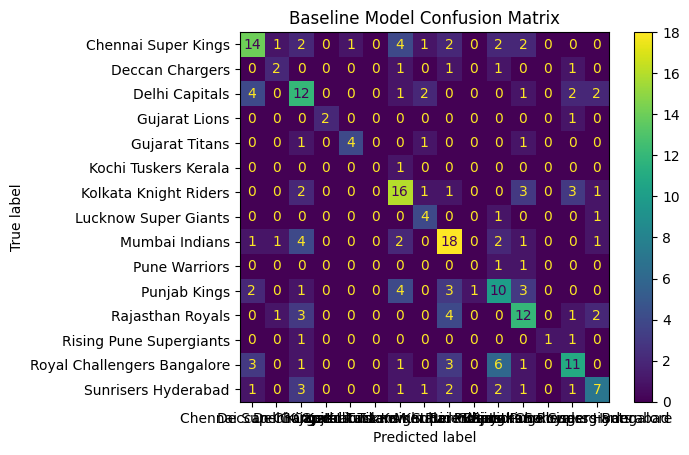

In [ ]:
# ===============================
# Confusion Matrix Visualization
# ===============================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Baseline Model Confusion Matrix")
plt.show()

In [ ]:
# ===============================
# Model 2 - Baseline + Last 7 Match Form
# ===============================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Features: baseline + last7 form
features = [
    "team1",
    "team2",
    "venue",
    "toss_winner",
    "toss_decision",
    "team1_last7_form",
    "team2_last7_form"
]

X = match_df[features]
y = match_df["winner"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Categorical columns
categorical_cols = ["team1", "team2", "venue", "toss_winner", "toss_decision"]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

# Pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Model 2 Results (Baseline + Last 7 Form)")
print("----------------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Model 2 Results (Baseline + Last 7 Form)
----------------------------------------
Accuracy : 0.5043478260869565
Precision: 0.5099655858345337
Recall   : 0.5043478260869565
F1 Score : 0.5020423167344495


d:\Projects\DeepSeek Project\cricket-match-prediction-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
print(match_df.columns)

Index(['match_id', 'team1', 'team2', 'toss_winner', 'toss_decision', 'venue',
       'city', 'winner', 'team1_win_pct', 'team2_win_pct',
       'head_to_head_win_pct', 'team1_home', 'team2_home', 'chasing_team',
       'chasing_team_won', 'venue_chasing_rate', 'team1_won_toss',
       'toss_decision_field', 'team1_chasing', 'team1_last7_form',
       'team2_last7_form'],
      dtype='object')


In [ ]:
# ===============================
# Chronological Train-Test Split
# ===============================

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Features
features = [
    "team1",
    "team2",
    "venue",
    "toss_winner",
    "toss_decision",
    "team1_last7_form",
    "team2_last7_form"
]

X = match_df[features]
y = match_df["winner"]

# Chronological split
split_index = int(len(match_df) * 0.8)

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

# Categorical columns
categorical_cols = ["team1","team2","venue","toss_winner","toss_decision"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Chronological Model Results")
print("----------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Chronological Model Results
----------------------------
Accuracy : 0.4652173913043478
Precision: 0.48414688950009527
Recall   : 0.4652173913043478
F1 Score : 0.4332376903920248


In [ ]:
# ===============================
# Model with ALL Features
# Chronological Split
# ===============================

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# All features
features = [
    "team1",
    "team2",
    "venue",
    "toss_winner",
    "toss_decision",
    "team1_win_pct",
    "team2_win_pct",
    "head_to_head_win_pct",
    "team1_venue_win_pct",
    "team1_home",
    "team2_home",
    "venue_chasing_rate",
    "team1_won_toss",
    "toss_decision_field",
    "team1_chasing",
    "team1_last7_form",
    "team2_last7_form"
]

X = match_df[features]
y = match_df["winner"]

# chronological split
split_index = int(len(match_df) * 0.8)

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

# categorical features
categorical_cols = ["team1","team2","venue","toss_winner","toss_decision"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

# train
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("All Feature Model Results")
print("-------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

KeyError: "['team1_venue_win_pct'] not in index"

In [ ]:
# ===============================
# Create Binary Target Variable
# ===============================

match_df["team1_win"] = (match_df["winner"] == match_df["team1"]).astype(int)

# check
match_df[["team1","team2","winner","team1_win"]].head()
# ===============================
# Binary Match Prediction Model
# ===============================

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Features
features = [
    "team1",
    "team2",
    "venue",
    "toss_winner",
    "toss_decision",
    "team1_win_pct",
    "team2_win_pct",
    "head_to_head_win_pct",
    "team1_venue_win_pct",
    "team1_home",
    "team2_home",
    "venue_chasing_rate",
    "team1_won_toss",
    "toss_decision_field",
    "team1_chasing",
    "team1_last7_form",
    "team2_last7_form"
]

X = match_df[features]
y = match_df["team1_win"]

# chronological split
split_index = int(len(match_df) * 0.8)

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

# categorical columns
categorical_cols = ["team1","team2","venue","toss_winner","toss_decision"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

# train
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Binary Match Prediction Results")
print("--------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Binary Match Prediction Results
--------------------------------
Accuracy : 0.6434782608695652
Precision: 0.6571428571428571
Recall   : 0.6
F1 Score : 0.6272727272727273


In [ ]:
# ===============================
# Random Forest Model
# ===============================

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

features = [
    "team1",
    "team2",
    "venue",
    "toss_winner",
    "toss_decision",
    "team1_win_pct",
    "team2_win_pct",
    "head_to_head_win_pct",
    "team1_venue_win_pct",
    "team1_home",
    "team2_home",
    "venue_chasing_rate",
    "team1_won_toss",
    "toss_decision_field",
    "team1_chasing",
    "team1_last7_form",
    "team2_last7_form"
]

X = match_df[features]
y = match_df["team1_win"]

split_index = int(len(match_df) * 0.8)

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

categorical_cols = ["team1","team2","venue","toss_winner","toss_decision"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Random Forest Results
---------------------
Accuracy : 0.6260869565217392
Precision: 0.6559139784946236
Recall   : 0.5304347826086957
F1 Score : 0.5865384615384616


In [ ]:
# ===============================
# Create difference features
# ===============================

match_df["win_pct_diff"] = match_df["team1_win_pct"] - match_df["team2_win_pct"]

match_df["form_diff"] = match_df["team1_last7_form"] - match_df["team2_last7_form"]

match_df["home_advantage"] = match_df["team1_home"] - match_df["team2_home"]

match_df.head()
# ===============================
# Logistic Regression with Difference Features
# ===============================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

features = [
    "team1",
    "team2",
    "venue",
    "toss_winner",
    "toss_decision",
    "win_pct_diff",
    "head_to_head_win_pct",
    "form_diff",
    "home_advantage",
    "venue_chasing_rate",
    "team1_won_toss",
    "toss_decision_field",
    "team1_chasing"
]

X = match_df[features]
y = match_df["team1_win"]

split_index = int(len(match_df) * 0.8)

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

categorical_cols = ["team1","team2","venue","toss_winner","toss_decision"]

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Difference Feature Model Results")
print("---------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Difference Feature Model Results
---------------------------------
Accuracy : 0.5173913043478261
Precision: 0.5192307692307693
Recall   : 0.46956521739130436
F1 Score : 0.4931506849315068


In [ ]:
# ===============================
# SVM Model
# ===============================

from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

features = [
    "team1",
    "team2",
    "venue",
    "toss_winner",
    "toss_decision",
    "team1_win_pct",
    "team2_win_pct",
    "head_to_head_win_pct",
    "team1_venue_win_pct",
    "team1_home",
    "team2_home",
    "venue_chasing_rate",
    "team1_won_toss",
    "toss_decision_field",
    "team1_chasing",
    "team1_last7_form",
    "team2_last7_form"
]

X = match_df[features]
y = match_df["team1_win"]

# chronological split
split_index = int(len(match_df) * 0.8)

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

categorical_cols = ["team1","team2","venue","toss_winner","toss_decision"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(kernel="rbf"))
])

# train
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("SVM Model Results")
print("-----------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

SVM Model Results
-----------------
Accuracy : 0.5956521739130435
Precision: 0.6195652173913043
Recall   : 0.4956521739130435
F1 Score : 0.5507246376811594


In [ ]:
# ===============================
# XGBoost Model
# ===============================

from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

features = [
    "team1",
    "team2",
    "venue",
    "toss_winner",
    "toss_decision",
    "team1_win_pct",
    "team2_win_pct",
    "head_to_head_win_pct",
    "team1_venue_win_pct",
    "team1_home",
    "team2_home",
    "venue_chasing_rate",
    "team1_won_toss",
    "toss_decision_field",
    "team1_chasing",
    "team1_last7_form",
    "team2_last7_form"
]

X = match_df[features]
y = match_df["team1_win"]

split_index = int(len(match_df) * 0.8)

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

categorical_cols = ["team1","team2","venue","toss_winner","toss_decision"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("XGBoost Results")
print("----------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

d:\Projects\DeepSeek Project\cricket-match-prediction-ml\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:21:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Results
----------------
Accuracy : 0.5782608695652174
Precision: 0.59
Recall   : 0.5130434782608696
F1 Score : 0.5488372093023256


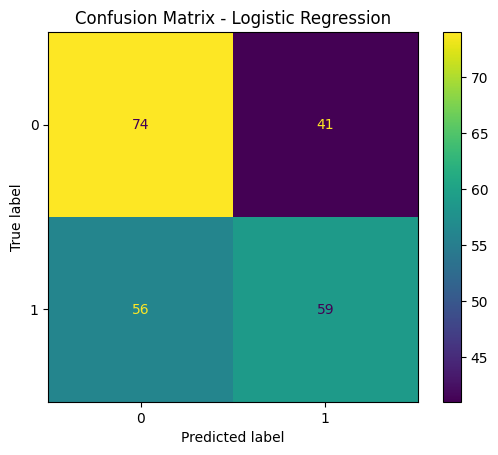

In [ ]:
# ===============================
# Confusion Matrix for Logistic Regression
# ===============================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
# ===============================
# 5-Fold Cross Validation
# ===============================

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")

print("Cross Validation Accuracies:", scores)
print("Mean Accuracy:", scores.mean())

Cross Validation Accuracies: [0.70869565 0.71615721 0.64628821 0.62008734 0.6419214 ]
Mean Accuracy: 0.6666299601291058


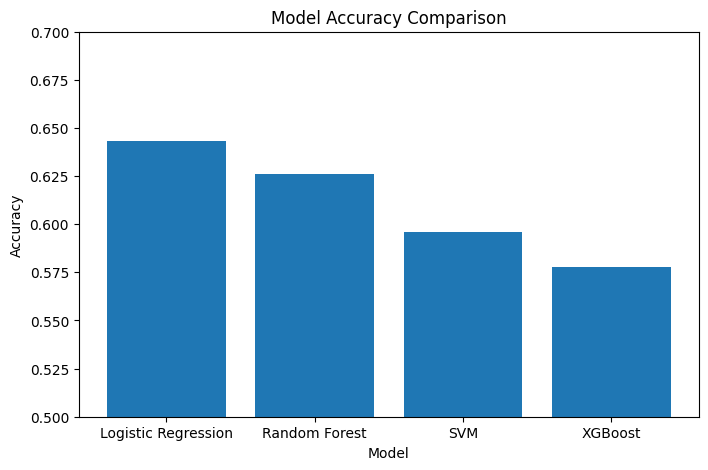

In [ ]:
# ===============================
# Model Accuracy Comparison Graph
# ===============================

import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "Random Forest",
    "SVM",
    "XGBoost"
]

accuracies = [
    0.643,
    0.626,
    0.596,
    0.578
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.ylim(0.5,0.7)

plt.show()

In [ ]:
# ===============================
# Re-train Logistic Regression and show feature importance
# ===============================

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import numpy as np

features = [
    "team1",
    "team2",
    "venue",
    "toss_winner",
    "toss_decision",
    "team1_win_pct",
    "team2_win_pct",
    "head_to_head_win_pct",
    "team1_venue_win_pct",
    "team1_home",
    "team2_home",
    "venue_chasing_rate",
    "team1_won_toss",
    "toss_decision_field",
    "team1_chasing",
    "team1_last7_form",
    "team2_last7_form"
]

X = match_df[features]
y = match_df["team1_win"]

categorical_cols = ["team1","team2","venue","toss_winner","toss_decision"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

# train model on full dataset
model.fit(X, y)

# get feature names
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# get coefficients
coefficients = model.named_steps["classifier"].coef_[0]

# sort importance
importance = sorted(
    zip(feature_names, coefficients),
    key=lambda x: abs(x[1]),
    reverse=True
)

print("Top Influential Features:\n")

for f, c in importance[:15]:
    print(f"{f} : {c}")

Top Influential Features:

remainder__team1_venue_win_pct : 2.980006713762998
remainder__head_to_head_win_pct : 2.409674970086574
cat__toss_winner_Rising Pune Supergiants : -0.9722683136834972
cat__team2_Gujarat Lions : -0.6535775485568059
cat__toss_winner_Kochi Tuskers Kerala : -0.62199305072207
cat__toss_winner_Pune Warriors : 0.5934524482005422
cat__team2_Chennai Super Kings : -0.45640605338859314
cat__toss_winner_Mumbai Indians : 0.438001144534838
cat__team2_Deccan Chargers : 0.43758278797453953
cat__team2_Pune Warriors : 0.4152736399469398
cat__team1_Chennai Super Kings : -0.3880939514019503
cat__toss_winner_Lucknow Super Giants : 0.38691967314651654
cat__toss_winner_Chennai Super Kings : 0.37654104839539293
cat__toss_winner_Gujarat Titans : -0.32800285129541434
cat__venue_Holkar Cricket Stadium : -0.32434048578746655


<Figure size 600x500 with 0 Axes>

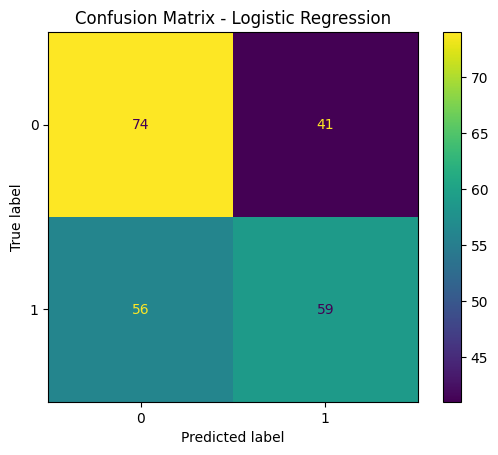


Cross Validation Results
------------------------
Fold Accuracies : [0.70869565 0.71615721 0.64628821 0.62008734 0.6419214 ]
Mean Accuracy   : 0.6666299601291058
Std Deviation   : 0.03850450929695225


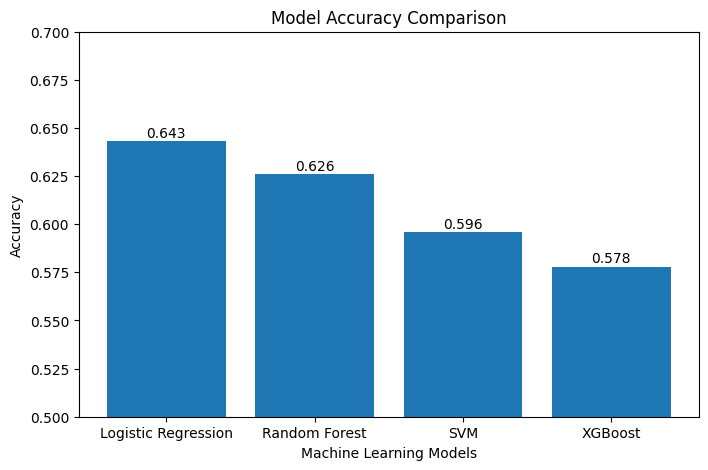

In [ ]:
# =========================================================
# FINAL MODEL EVALUATION
# Confusion Matrix + Cross Validation + Accuracy Graph
# =========================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# -----------------------------
# 1️⃣ Confusion Matrix
# -----------------------------
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


# -----------------------------
# 2️⃣ Cross Validation
# -----------------------------
cv_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

scores = cross_val_score(cv_model, X, y, cv=5, scoring="accuracy")

print("\nCross Validation Results")
print("------------------------")
print("Fold Accuracies :", scores)
print("Mean Accuracy   :", np.mean(scores))
print("Std Deviation   :", np.std(scores))


# -----------------------------
# 3️⃣ Model Accuracy Comparison Graph
# -----------------------------
models = [
    "Logistic Regression",
    "Random Forest",
    "SVM",
    "XGBoost"
]

accuracies = [
    0.643,
    0.626,
    0.596,
    0.578
]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Machine Learning Models")
plt.ylim(0.5,0.7)

# add accuracy labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.002,
             f"{acc:.3f}", ha='center')

plt.show()


Random Split Results
---------------------
Accuracy : 0.6043478260869565
Precision: 0.5252525252525253
Recall   : 0.5416666666666666
F1 Score : 0.5333333333333333


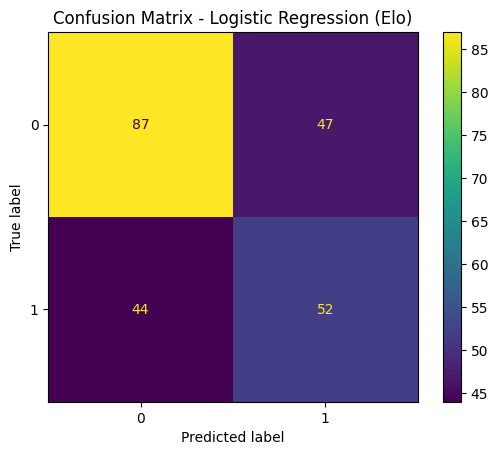


10-Fold Cross Validation Results
--------------------------------
Fold Accuracies : [0.53043478 0.64347826 0.62608696 0.60869565 0.66956522 0.5826087
 0.53508772 0.50877193 0.54385965 0.49122807]
Mean Accuracy   : 0.5739816933638443
Std Deviation   : 0.05777310198521272


In [ ]:
# =========================================================
# IPL MATCH PREDICTION WITH ELO FEATURE
# RANDOM SPLIT + 10-FOLD CROSS VALIDATION
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay


# ---------------------------------------------------------
# 1️⃣ Sort dataset
# ---------------------------------------------------------
match_df = match_df.sort_values("match_id").reset_index(drop=True)


# ---------------------------------------------------------
# 2️⃣ Create target variable
# ---------------------------------------------------------
match_df["team1_win"] = (match_df["winner"] == match_df["team1"]).astype(int)


# ---------------------------------------------------------
# 3️⃣ Initialize Elo ratings
# ---------------------------------------------------------
teams = pd.unique(match_df[['team1','team2']].values.ravel())
elo_ratings = {team:1500 for team in teams}

elo_team1 = []
elo_team2 = []

K = 20


# ---------------------------------------------------------
# 4️⃣ Calculate Elo ratings sequentially
# ---------------------------------------------------------
for idx,row in match_df.iterrows():

    team1 = row["team1"]
    team2 = row["team2"]
    winner = row["winner"]

    r1 = elo_ratings[team1]
    r2 = elo_ratings[team2]

    elo_team1.append(r1)
    elo_team2.append(r2)

    e1 = 1/(1+10**((r2-r1)/400))
    e2 = 1/(1+10**((r1-r2)/400))

    if winner == team1:
        s1 = 1
        s2 = 0
    else:
        s1 = 0
        s2 = 1

    elo_ratings[team1] = r1 + K*(s1-e1)
    elo_ratings[team2] = r2 + K*(s2-e2)


match_df["team1_elo"] = elo_team1
match_df["team2_elo"] = elo_team2
match_df["elo_diff"] = match_df["team1_elo"] - match_df["team2_elo"]


# ---------------------------------------------------------
# 5️⃣ Feature list
# ---------------------------------------------------------
features = [
    "team1",
    "team2",
    "venue",
    "toss_winner",
    "toss_decision",
    "team1_win_pct",
    "team2_win_pct",
    "head_to_head_win_pct",
    "team1_home",
    "team2_home",
    "venue_chasing_rate",
    "team1_won_toss",
    "toss_decision_field",
    "team1_chasing",
    "team1_last7_form",
    "team2_last7_form",
    "elo_diff"
]

X = match_df[features]
y = match_df["team1_win"]


# ---------------------------------------------------------
# 6️⃣ Random Train-Test Split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ---------------------------------------------------------
# 7️⃣ Preprocessing
# ---------------------------------------------------------
categorical_cols = [
    "team1",
    "team2",
    "venue",
    "toss_winner",
    "toss_decision"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)


# ---------------------------------------------------------
# 8️⃣ Logistic Regression model
# ---------------------------------------------------------
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])


# ---------------------------------------------------------
# 9️⃣ Train model
# ---------------------------------------------------------
model.fit(X_train, y_train)


# ---------------------------------------------------------
# 🔟 Predictions
# ---------------------------------------------------------
y_pred = model.predict(X_test)


# ---------------------------------------------------------
# 1️⃣1️⃣ Evaluation
# ---------------------------------------------------------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nRandom Split Results")
print("---------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


# ---------------------------------------------------------
# 1️⃣2️⃣ Confusion Matrix
# ---------------------------------------------------------
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Logistic Regression (Elo)")
plt.show()


# ---------------------------------------------------------
# 1️⃣3️⃣ 10-Fold Cross Validation
# ---------------------------------------------------------
scores = cross_val_score(model, X, y, cv=10, scoring="accuracy")

print("\n10-Fold Cross Validation Results")
print("--------------------------------")
print("Fold Accuracies :", scores)
print("Mean Accuracy   :", np.mean(scores))
print("Std Deviation   :", np.std(scores))